# HW10-11: Компьютерное зрение в PyTorch

**Часть A (S10):** CNN, аугментации, transfer learning — датасет **CIFAR-100**
**Часть B (S11):** Семантическая сегментация — **Pascal VOC 2007**, модель DeepLabV3

| Эксперимент | Описание |
|---|---|
| C1 | Простая CNN без аугментаций |
| C2 | Простая CNN с аугментациями |
| C3 | ResNet18, head-only (backbone заморожен) |
| C4 | ResNet18, частичный fine-tune (layer4 + fc) |
| V1 | Сегментация: базовая постобработка (softmax threshold > 0.5) |
| V2 | Сегментация: морфологическая очистка (binary opening 7×7) |

## 1. Импорты, seed и устройство

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import json, csv, os, copy
from pathlib import Path
from PIL import Image
from scipy.ndimage import binary_opening

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__}, torchvision {torchvision.__version__}")
print(f"Device: {device}")

DATA_DIR     = './data'
ARTIFACTS_DIR = './artifacts'
FIGURES_DIR  = './artifacts/figures'
for d in [DATA_DIR, ARTIFACTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

PyTorch 2.10.0+cpu, torchvision 0.25.0+cpu
Device: cpu


---
# Часть A (S10): Классификация — CIFAR-100

## 2. Загрузка данных

**CIFAR-100** — 100 классов, 32×32 RGB, 50 000 train + 10 000 test.

**Validation split:** CIFAR-100 не имеет официального validation split, поэтому выполняем разбиение train → train/val (80%/20%) с фиксированным seed=42.
Для быстрого обучения на CPU используем подвыборку: 10 000 train / 2 500 val.

In [2]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Transforms для простой CNN (32×32)
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Transforms для ResNet (96×96 — компромисс для CPU; AdaptiveAvgPool в ResNet обрабатывает любой размер)
transform_resnet_train = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_resnet_val = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transforms определены.")

Transforms определены.


In [3]:
# Загрузка CIFAR-100
cifar_full = torchvision.datasets.CIFAR100(
    root=DATA_DIR, train=True, download=True, transform=transform_base)
cifar_test_base = torchvision.datasets.CIFAR100(
    root=DATA_DIR, train=False, download=True, transform=transform_base)

NUM_CLASSES = 100
CLASS_NAMES = cifar_full.classes
print(f"Train size: {len(cifar_full)}, Test size: {len(cifar_test_base)}")
print(f"Число классов: {NUM_CLASSES}")
print(f"Примеры классов: {CLASS_NAMES[:10]}...")

Train size: 50000, Test size: 10000
Число классов: 100
Примеры классов: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']...


In [ ]:
# ==== Train / Validation split ====
# CIFAR-100 не имеет официального validation split,
# поэтому разбиваем train на train/val (80%/20%) с фиксированным seed.
# Используем подвыборку для быстрого обучения на CPU.
n_train_sub, n_val_sub = 10000, 2500  # соотношение 80% / 20%
indices = np.random.RandomState(SEED).permutation(len(cifar_full))
train_idx = indices[:n_train_sub].tolist()
val_idx   = indices[n_train_sub:n_train_sub + n_val_sub].tolist()

print(f"Validation split (seed={SEED}):")
print(f"  Train: {len(train_idx)}, Val: {len(val_idx)}")
print(f"  Соотношение: {len(train_idx)/(len(train_idx)+len(val_idx))*100:.0f}% / {len(val_idx)/(len(train_idx)+len(val_idx))*100:.0f}%")
print(f"  Test (official): {len(cifar_test_base)}")

def make_loaders(train_tf, val_tf, batch_size):
    ds_tr = torchvision.datasets.CIFAR100(root=DATA_DIR, train=True,
                                          download=False, transform=train_tf)
    ds_vl = torchvision.datasets.CIFAR100(root=DATA_DIR, train=True,
                                          download=False, transform=val_tf)
    ds_te = torchvision.datasets.CIFAR100(root=DATA_DIR, train=False,
                                          download=False, transform=val_tf)
    trl = DataLoader(Subset(ds_tr, train_idx), batch_size=batch_size,
                     shuffle=True, num_workers=0)
    vll = DataLoader(Subset(ds_vl, val_idx),   batch_size=batch_size,
                     shuffle=False, num_workers=0)
    tel = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=0)
    return trl, vll, tel

## 3. Sanity-check

x.shape = torch.Size([16, 3, 32, 32]), y.shape = torch.Size([16])
x dtype=torch.float32, range=[-2.12, 2.64]
Labels: [4, 73, 9, 34, 83, 18, 55, 19] → ['beaver', 'shark', 'bottle', 'fox', 'sweet_pepper', 'caterpillar', 'otter', 'cattle']


Sanity-check пройден.


  plt.show()


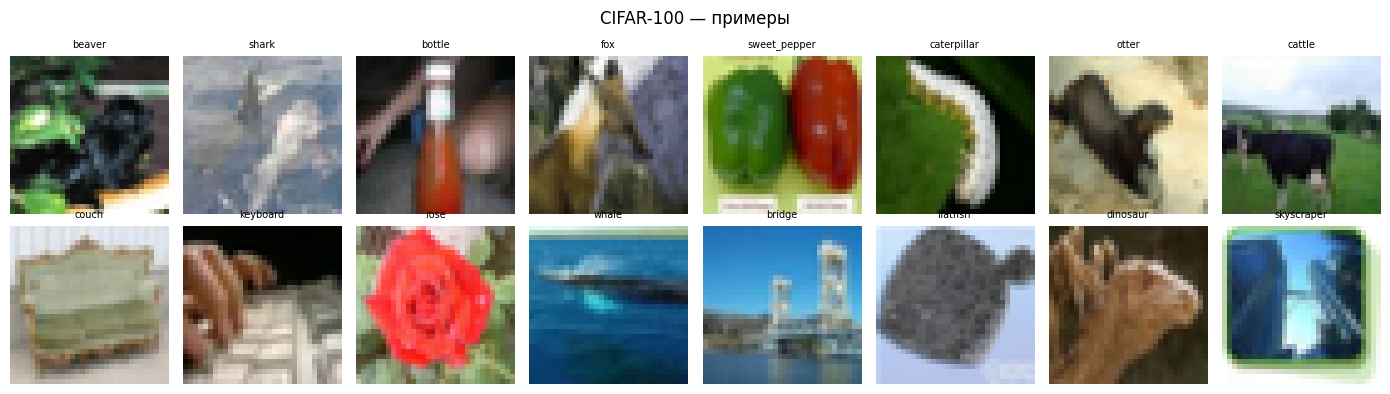

In [5]:
tmp_loader, _, _ = make_loaders(transform_base, transform_base, 16)
xb, yb = next(iter(tmp_loader))
print(f"x.shape = {xb.shape}, y.shape = {yb.shape}")
print(f"x dtype={xb.dtype}, range=[{xb.min():.2f}, {xb.max():.2f}]")
print(f"Labels: {yb[:8].tolist()} → {[CLASS_NAMES[i] for i in yb[:8].tolist()]}")

def denorm(t, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = t.clone()
    for ch in range(3):
        t[ch] = t[ch]*std[ch] + mean[ch]
    return t.clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(16):
    ax = axes[i//8][i%8]
    ax.imshow(denorm(xb[i]).permute(1,2,0).numpy())
    ax.set_title(CLASS_NAMES[yb[i]][:12], fontsize=7)
    ax.axis('off')
fig.suptitle('CIFAR-100 — примеры', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'data_samples.png'), dpi=100, bbox_inches='tight')
plt.show()
print("Sanity-check пройден.")

## 4. Модели и функции обучения

In [6]:
class SimpleCNN(nn.Module):
    """CNN для 32×32 изображений."""
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 512), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

def make_resnet18(num_classes, freeze_backbone=True, unfreeze_layer4=False):
    w = models.ResNet18_Weights.IMAGENET1K_V1
    m = models.resnet18(weights=w)
    if freeze_backbone:
        for p in m.parameters(): p.requires_grad = False
    if unfreeze_layer4:
        for p in m.layer4.parameters(): p.requires_grad = True
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

print(f"SimpleCNN params: {sum(p.numel() for p in SimpleCNN().parameters()):,}")
r_ho = make_resnet18(NUM_CLASSES, True, False)
print(f"ResNet18 head-only trainable: {sum(p.numel() for p in r_ho.parameters() if p.requires_grad):,}")
r_ft = make_resnet18(NUM_CLASSES, True, True)
print(f"ResNet18 layer4+fc trainable: {sum(p.numel() for p in r_ft.parameters() if p.requires_grad):,}")
del r_ho, r_ft

SimpleCNN params: 1,194,084
ResNet18 head-only trainable: 51,300


ResNet18 layer4+fc trainable: 8,445,028


In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()*x.size(0)
        correct += (out.argmax(1)==y).sum().item()
        total += x.size(0)
    return loss_sum/total, correct/total

def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            loss_sum += loss.item()*x.size(0)
            correct += (out.argmax(1)==y).sum().item()
            total += x.size(0)
    return loss_sum/total, correct/total

def run_experiment(model, trl, vll, epochs, lr, device, name):
    model = model.to(device)
    crit = nn.CrossEntropyLoss()
    opt  = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    hist = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_acc, best_st = 0.0, None
    for ep in range(1, epochs+1):
        tl, ta = train_one_epoch(model, trl, crit, opt, device)
        vl, va = evaluate(model, vll, crit, device)
        hist['train_loss'].append(tl); hist['val_loss'].append(vl)
        hist['train_acc'].append(ta); hist['val_acc'].append(va)
        if va > best_acc:
            best_acc = va; best_st = copy.deepcopy(model.state_dict())
        if ep%5==0 or ep==1 or ep==epochs:
            print(f"  [{name}] {ep:>2}/{epochs}  tl={tl:.4f} ta={ta:.4f} vl={vl:.4f} va={va:.4f}")
    print(f"  [{name}] best val_acc = {best_acc:.4f}")
    return hist, best_acc, best_st

print("Функции обучения готовы.")

Функции обучения готовы.


---
## 5. Эксперименты C1–C4

| | Loss | Optimizer | Seed | Split |
|---|---|---|---|---|
| Все | CrossEntropyLoss | Adam | 42 | 80/20 |

### C1: Simple CNN — без аугментаций

In [8]:
CNN_EP, CNN_LR, CNN_BS = 10, 1e-3, 128
trl1, vll1, _ = make_loaders(transform_base, transform_base, CNN_BS)
torch.manual_seed(SEED); np.random.seed(SEED)
model_c1 = SimpleCNN(NUM_CLASSES)
print(f"C1: SimpleCNN, ep={CNN_EP}, lr={CNN_LR}, bs={CNN_BS}, no aug")
h1, a1, s1 = run_experiment(model_c1, trl1, vll1, CNN_EP, CNN_LR, device, 'C1')

C1: SimpleCNN, ep=10, lr=0.001, bs=128, no aug


  [C1]  1/10  tl=4.3199 ta=0.0519 vl=3.9263 va=0.0996


  [C1]  5/10  tl=3.2624 ta=0.1932 vl=3.1815 va=0.2344


  [C1] 10/10  tl=2.6753 ta=0.3083 vl=2.8618 va=0.2844
  [C1] best val_acc = 0.2892


### C2: Simple CNN — с аугментациями

augmentations_preview.png сохранён


  plt.show()


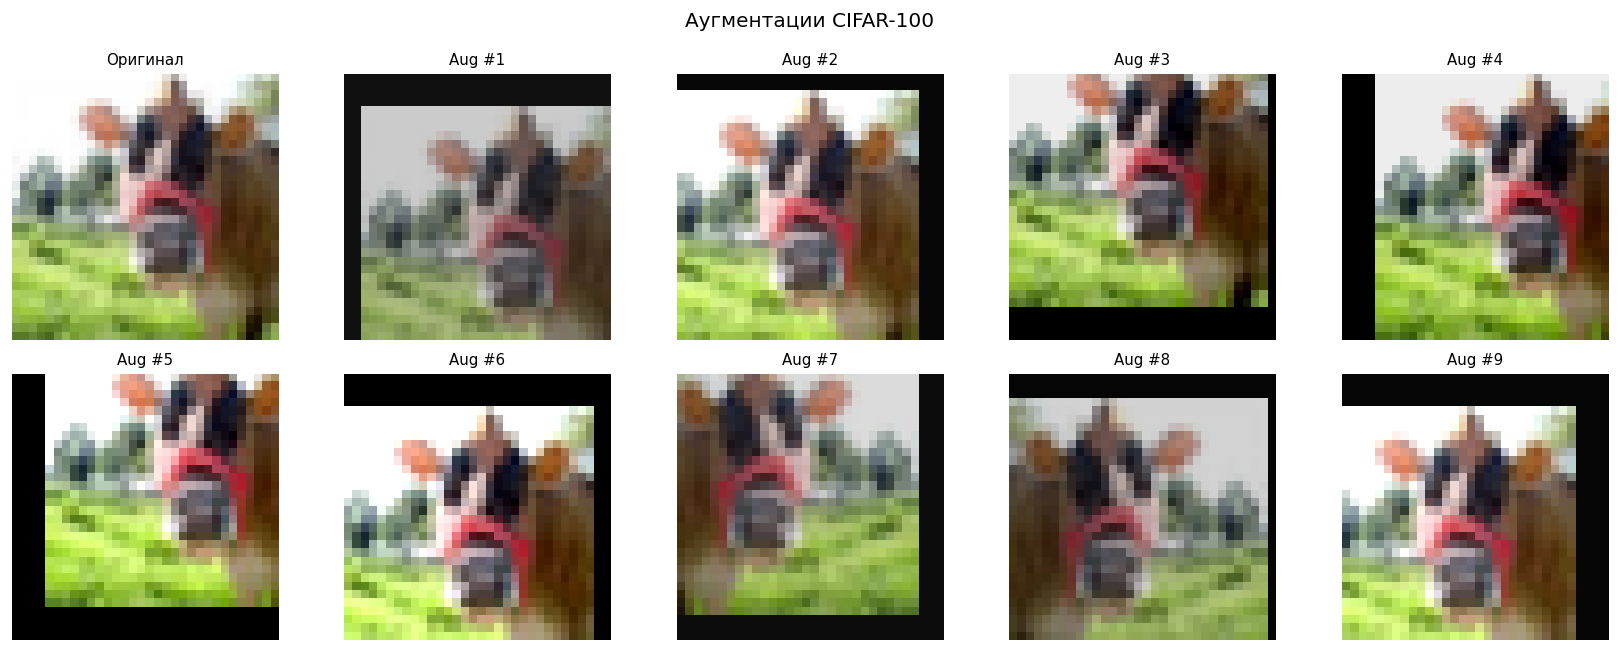

In [9]:
# Визуализация аугментаций
raw = torchvision.datasets.CIFAR100(root=DATA_DIR, train=True, download=False)
sample_pil = raw[0][0]

fig, axes = plt.subplots(2, 5, figsize=(14, 5.5))
axes[0][0].imshow(sample_pil); axes[0][0].set_title('Оригинал',fontsize=9); axes[0][0].axis('off')
aug_vis = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5), transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(0.2, 0.2, 0.2),
])
for i in range(1, 10):
    ax = axes[i//5][i%5]
    ax.imshow(aug_vis(sample_pil)); ax.set_title(f'Aug #{i}',fontsize=9); ax.axis('off')
fig.suptitle('Аугментации CIFAR-100', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'augmentations_preview.png'), dpi=120, bbox_inches='tight')
plt.show()
print("augmentations_preview.png сохранён")

In [10]:
trl2, vll2, _ = make_loaders(transform_aug, transform_base, CNN_BS)
torch.manual_seed(SEED); np.random.seed(SEED)
model_c2 = SimpleCNN(NUM_CLASSES)
print(f"C2: SimpleCNN + aug, ep={CNN_EP}, lr={CNN_LR}, bs={CNN_BS}")
h2, a2, s2 = run_experiment(model_c2, trl2, vll2, CNN_EP, CNN_LR, device, 'C2')

C2: SimpleCNN + aug, ep=10, lr=0.001, bs=128


  [C2]  1/10  tl=4.4025 ta=0.0425 vl=4.0221 va=0.0812


  [C2]  5/10  tl=3.6441 ta=0.1296 vl=3.3966 va=0.1920


  [C2] 10/10  tl=3.2821 ta=0.1887 vl=3.0597 va=0.2564
  [C2] best val_acc = 0.2564


### C3: ResNet18 — head-only

In [11]:
RN_EP, RN_LR_H, RN_BS = 5, 1e-3, 64
trl3, vll3, _ = make_loaders(transform_resnet_train, transform_resnet_val, RN_BS)
torch.manual_seed(SEED); np.random.seed(SEED)
model_c3 = make_resnet18(NUM_CLASSES, freeze_backbone=True, unfreeze_layer4=False)
print(f"C3: ResNet18 head-only, ep={RN_EP}, lr={RN_LR_H}, bs={RN_BS}")
h3, a3, s3 = run_experiment(model_c3, trl3, vll3, RN_EP, RN_LR_H, device, 'C3')

C3: ResNet18 head-only, ep=5, lr=0.001, bs=64


  [C3]  1/5  tl=3.2634 ta=0.2762 vl=2.3598 va=0.4384


  [C3]  5/5  tl=1.4076 ta=0.6217 vl=1.8648 va=0.5148
  [C3] best val_acc = 0.5152


### C4: ResNet18 — partial fine-tune (layer4 + fc)

In [12]:
RN_LR_FT = 1e-4
trl4, vll4, _ = make_loaders(transform_resnet_train, transform_resnet_val, RN_BS)
torch.manual_seed(SEED); np.random.seed(SEED)
model_c4 = make_resnet18(NUM_CLASSES, freeze_backbone=True, unfreeze_layer4=True)
print(f"C4: ResNet18 layer4+fc, ep={RN_EP}, lr={RN_LR_FT}, bs={RN_BS}")
h4, a4, s4 = run_experiment(model_c4, trl4, vll4, RN_EP, RN_LR_FT, device, 'C4')

C4: ResNet18 layer4+fc, ep=5, lr=0.0001, bs=64


  [C4]  1/5  tl=3.1914 ta=0.3073 vl=2.0961 va=0.5184


  [C4]  5/5  tl=0.4424 ta=0.9199 vl=1.3084 va=0.6476
  [C4] best val_acc = 0.6476


---
## 6. Сравнение C1–C4 и выбор лучшей модели

In [13]:
results_a = {
    'C1': dict(h=h1,ba=a1,st=s1,ms='SimpleCNN',lr=CNN_LR,ep=CNN_EP,bs=CNN_BS,
               opt='Adam',note='SimpleCNN, no augmentation'),
    'C2': dict(h=h2,ba=a2,st=s2,ms='SimpleCNN',lr=CNN_LR,ep=CNN_EP,bs=CNN_BS,
               opt='Adam',note='SimpleCNN + augmentations'),
    'C3': dict(h=h3,ba=a3,st=s3,ms='ResNet18 head-only',lr=RN_LR_H,ep=RN_EP,bs=RN_BS,
               opt='Adam',note='ResNet18 pretrained, backbone frozen'),
    'C4': dict(h=h4,ba=a4,st=s4,ms='ResNet18 layer4+fc',lr=RN_LR_FT,ep=RN_EP,bs=RN_BS,
               opt='Adam',note='ResNet18 pretrained, partial fine-tune'),
}
print(f"{'Exp':>4} {'val_acc':>10}  Note")
print("-"*55)
for k,v in results_a.items():
    print(f"{k:>4} {v['ba']:>10.4f}  {v['note']}")

best_id = max(results_a, key=lambda k: results_a[k]['ba'])
print(f"\nЛучший: {best_id}  val_acc={results_a[best_id]['ba']:.4f}")

 Exp    val_acc  Note
-------------------------------------------------------
  C1     0.2892  SimpleCNN, no augmentation
  C2     0.2564  SimpleCNN + augmentations
  C3     0.5152  ResNet18 pretrained, backbone frozen
  C4     0.6476  ResNet18 pretrained, partial fine-tune

Лучший: C4  val_acc=0.6476


  plt.show()


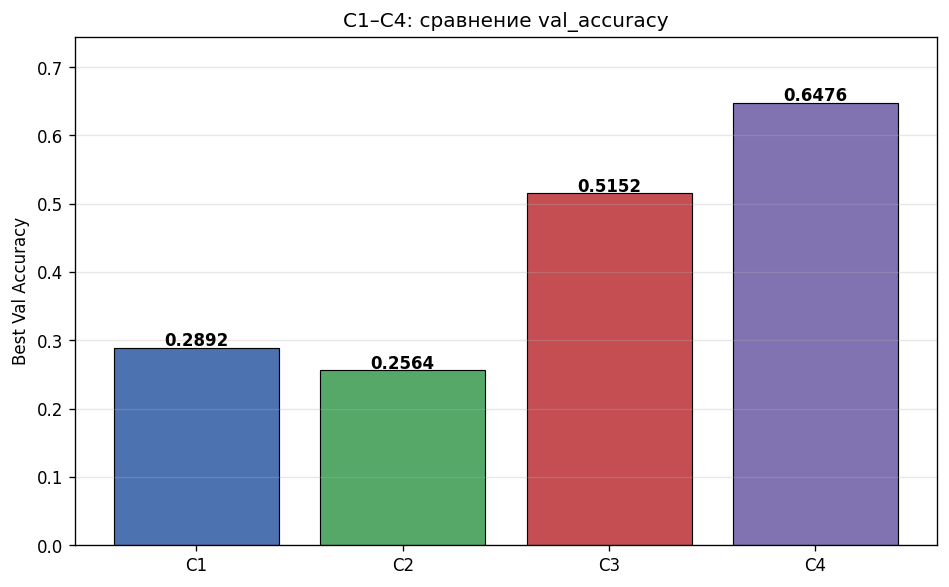

In [14]:
# Bar chart
ids = list(results_a.keys())
accs = [results_a[k]['ba'] for k in ids]
cols = ['#4C72B0','#55A868','#C44E52','#8172B2']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(ids, accs, color=cols, edgecolor='k', linewidth=.7)
for b,a in zip(bars, accs):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+.003,
            f'{a:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Best Val Accuracy'); ax.set_title('C1–C4: сравнение val_accuracy')
ax.set_ylim(0, max(accs)*1.15); ax.grid(axis='y', alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,'classification_compare.png'), dpi=120, bbox_inches='tight')
plt.show()

  plt.show()


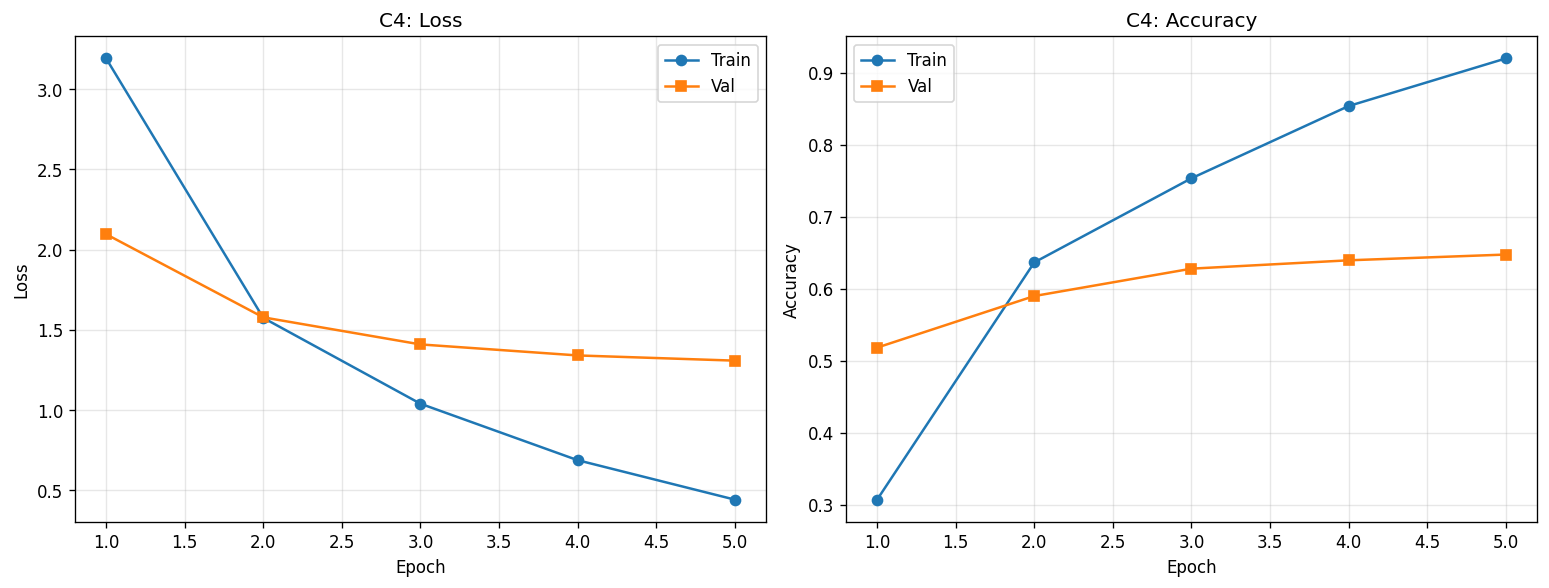

In [15]:
# Кривые лучшей модели
bh = results_a[best_id]['h']
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,5))
ep_r = range(1, len(bh['train_loss'])+1)
a1.plot(ep_r, bh['train_loss'],'o-',label='Train'); a1.plot(ep_r, bh['val_loss'],'s-',label='Val')
a1.set_xlabel('Epoch'); a1.set_ylabel('Loss'); a1.set_title(f'{best_id}: Loss'); a1.legend(); a1.grid(alpha=.3)
a2.plot(ep_r, bh['train_acc'],'o-',label='Train'); a2.plot(ep_r, bh['val_acc'],'s-',label='Val')
a2.set_xlabel('Epoch'); a2.set_ylabel('Accuracy'); a2.set_title(f'{best_id}: Accuracy'); a2.legend(); a2.grid(alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,'classification_curves_best.png'), dpi=120, bbox_inches='tight')
plt.show()

## 7. Финальная оценка лучшей модели на test

In [16]:
if best_id in ('C1','C2'):
    best_model = SimpleCNN(NUM_CLASSES).to(device)
    _, _, te_loader = make_loaders(transform_base, transform_base, CNN_BS)
elif best_id == 'C3':
    best_model = make_resnet18(NUM_CLASSES, True, False).to(device)
    _, _, te_loader = make_loaders(transform_resnet_train, transform_resnet_val, RN_BS)
else:
    best_model = make_resnet18(NUM_CLASSES, True, True).to(device)
    _, _, te_loader = make_loaders(transform_resnet_train, transform_resnet_val, RN_BS)

best_model.load_state_dict(results_a[best_id]['st'])
test_loss, test_acc = evaluate(best_model, te_loader, nn.CrossEntropyLoss(), device)
print(f"Лучший: {best_id}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Лучший: C4
Test Loss:     1.3364
Test Accuracy: 0.6315


## 8. Артефакты части A

In [17]:
torch.save(results_a[best_id]['st'], os.path.join(ARTIFACTS_DIR,'best_classifier.pt'))
br = results_a[best_id]
cfg = dict(dataset='CIFAR-100', experiment_id=best_id, architecture=br['ms'],
           optimizer=br['opt'], lr=br['lr'], batch_size=br['bs'],
           epochs=br['ep'], seed=SEED,
           best_val_accuracy=round(br['ba'],6), test_accuracy=round(test_acc,6),
           transforms=dict(normalize_mean=list(IMAGENET_MEAN),
                           normalize_std=list(IMAGENET_STD),
                           resize=[96,96] if best_id in ('C3','C4') else [32,32]),
           notes=br['note'])
with open(os.path.join(ARTIFACTS_DIR,'best_classifier_config.json'),'w',encoding='utf-8') as f:
    json.dump(cfg, f, indent=2, ensure_ascii=False)
print("best_classifier.pt и best_classifier_config.json сохранены.")

best_classifier.pt и best_classifier_config.json сохранены.


---
# Часть B (S11): Семантическая сегментация — Pascal VOC

**Модель:** DeepLabV3_ResNet50 (pretrained COCO+VOC, 21 класс)
**Foreground:** person (class 15)

Бинарная сегментация: person vs. всё остальное.

| Режим | Постобработка |
|---|---|
| V1 | softmax + confidence threshold (> 0.5) → бинарная маска |
| V2 | argmax + morphological opening (ядро 7×7) → очищенная маска |

## 9. Загрузка VOC и DeepLabV3

In [18]:
voc_tf = transforms.Compose([
    transforms.Resize((320,320)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
voc_target_tf = transforms.Compose([
    transforms.Resize((320,320), interpolation=transforms.InterpolationMode.NEAREST),
])

download_ok = False
for year in ['2007', '2012']:
    try:
        voc_ds = torchvision.datasets.VOCSegmentation(
            root=DATA_DIR, year=year, image_set='val', download=True,
            transform=voc_tf, target_transform=voc_target_tf)
        print(f"VOC {year} val: {len(voc_ds)} images")
        download_ok = True
        break
    except Exception as e:
        print(f"VOC {year} download failed: {e}")

if not download_ok:
    raise RuntimeError("Could not download Pascal VOC dataset")

VOC 2007 val: 213 images


In [19]:
seg_model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
seg_model.eval().to(device)
print("DeepLabV3_ResNet50 loaded")

VOC_CLASSES = ['background','aeroplane','bicycle','bird','boat','bottle','bus','car',
               'cat','chair','cow','diningtable','dog','horse','motorbike','person',
               'pottedplant','sheep','sofa','train','tvmonitor']
FG = 15
print(f"Foreground: '{VOC_CLASSES[FG]}' (id={FG})")

DeepLabV3_ResNet50 loaded
Foreground: 'person' (id=15)


## 10. Sanity-check сегментации

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    img_t, tgt = voc_ds[i]
    axes[0][i].imshow(denorm(img_t).permute(1,2,0).numpy()); axes[0][i].set_title(f'Image {i}'); axes[0][i].axis('off')
    axes[1][i].imshow(np.array(tgt), cmap='tab20', vmin=0, vmax=20); axes[1][i].set_title(f'GT {i}'); axes[1][i].axis('off')
fig.suptitle('VOC Segmentation — примеры', fontsize=13)
plt.tight_layout(); plt.show()

## 11. Метрики и инференс

In [ ]:
# ============================================================
# Работа с масками: извлечение GT, постобработка, метрики
# ============================================================

def extract_gt_mask(target, fg_class=FG):
    """Извлечение и обработка GT маски из VOC segmentation target.

    VOC segmentation target — PIL Image с попиксельными метками:
      0      : background
      1-20   : классы объектов VOC
      255    : void / border (игнорируется при оценке)

    Returns:
        gt_array   : np.ndarray [H,W] — полная карта классов GT
        fg_mask    : np.ndarray [H,W] bool — бинарная маска foreground
        valid_mask : np.ndarray [H,W] bool — валидные пиксели (не void)
    """
    gt_array = np.array(target)
    valid_mask = (gt_array != 255)          # исключаем void/border пиксели
    fg_mask = (gt_array == fg_class) & valid_mask  # бинарная маска foreground
    return gt_array, fg_mask, valid_mask


def postprocess_base(pred_logits, fg_class, threshold=0.5):
    """V1: базовая постобработка маски.

    Шаги:
      1. Вычисляем softmax по логитам → вероятности каждого класса
      2. Получаем argmax → карту классов
      3. Извлекаем бинарную маску foreground (pred == fg_class)
      4. Фильтруем по уверенности: оставляем fg только при P(fg) > threshold
      5. Неуверенные fg-пиксели переводятся в background (0)

    Порог 0.5 отсекает неуверенные предсказания, повышая precision.
    """
    # Softmax с вычитанием max для числовой стабильности
    shifted = pred_logits - pred_logits.max(axis=0, keepdims=True)
    exp_logits = np.exp(shifted)
    probs = exp_logits / exp_logits.sum(axis=0, keepdims=True)

    pred_labels = pred_logits.argmax(axis=0)
    fg_prob = probs[fg_class]                    # вероятность foreground-класса

    fg_mask = (pred_labels == fg_class)          # все пиксели, где argmax = fg
    confident = fg_mask & (fg_prob > threshold)  # оставляем уверенные

    result = pred_labels.copy()
    result[fg_mask & ~confident] = 0             # неуверенные → background
    return result


def postprocess_morph(pred_logits, fg_class, kernel_size=7):
    """V2: альтернативная постобработка — морфологическая очистка маски.

    Шаги:
      1. argmax по логитам → карта классов
      2. Извлекаем бинарную маску foreground
      3. Применяем binary opening (erosion → dilation) с ядром kernel_size×kernel_size
         Opening удаляет мелкие шумовые компоненты и сглаживает границы маски.
      4. Пиксели fg, удалённые opening, → background (0)
    """
    pred_labels = pred_logits.argmax(axis=0)
    fg_mask = (pred_labels == fg_class)

    struct = np.ones((kernel_size, kernel_size), dtype=bool)
    cleaned_mask = binary_opening(fg_mask, structure=struct)

    result = pred_labels.copy()
    result[fg_mask & ~cleaned_mask] = 0          # шумовые fg → background
    return result


def compute_seg_metrics(pred_labels, gt_array, valid_mask, fg_class=FG):
    """Вычисление метрик бинарной сегментации (foreground vs background).

    Метрики считаются ТОЛЬКО по валидным пикселям (void=255 игнорируется).

    Returns: dict(iou, prec, rec, has_fg)
    """
    gt_fg   = (gt_array == fg_class) & valid_mask
    pred_fg = (pred_labels == fg_class) & valid_mask

    tp = int(np.sum(pred_fg & gt_fg))
    fp = int(np.sum(pred_fg & ~gt_fg))
    fn = int(np.sum(~pred_fg & gt_fg))

    iou  = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else float('nan')
    prec = tp / (tp + fp)      if (tp + fp) > 0      else float('nan')
    rec  = tp / (tp + fn)      if (tp + fn) > 0      else float('nan')

    return dict(iou=iou, prec=prec, rec=rec, has_fg=bool(np.any(gt_fg)))


def run_segmentation(model, dataset, device, postprocess_fn, fg_class=FG, n_samples=50):
    """Инференс сегментации с постобработкой и вычислением метрик.

    Args:
        model           : pretrained segmentation model
        dataset         : VOCSegmentation dataset
        postprocess_fn  : функция (logits [C,H,W], fg_class) → pred_labels [H,W]
        fg_class        : id foreground-класса в VOC label space
        n_samples       : число изображений для оценки
    """
    metrics_list, vis = [], []
    for idx in range(min(n_samples, len(dataset))):
        img_t, tgt = dataset[idx]

        # --- Извлечение GT маски ---
        gt_array, gt_fg, valid_mask = extract_gt_mask(tgt, fg_class)

        # --- Инференс модели: получаем логиты [C, H, W] ---
        with torch.no_grad():
            logits = model(img_t.unsqueeze(0).to(device))['out'][0].cpu().numpy()

        # --- Постобработка предсказанной маски ---
        pred_labels = postprocess_fn(logits, fg_class)

        # --- Вычисление метрик ---
        m = compute_seg_metrics(pred_labels, gt_array, valid_mask, fg_class)
        m['idx'] = idx
        metrics_list.append(m)

        if len(vis) < 8:
            vis.append(dict(
                img=denorm(img_t).permute(1, 2, 0).numpy(),
                gt=gt_array, pred=pred_labels, m=m
            ))
        if (idx + 1) % 25 == 0:
            print(f"  processed {idx+1}/{min(n_samples, len(dataset))}")

    # Агрегация: среднее только по изображениям с foreground в GT
    fg_m = [m for m in metrics_list if m['has_fg']]
    summary = dict(
        mean_iou = float(np.nanmean([m['iou']  for m in fg_m])) if fg_m else 0.0,
        pix_prec = float(np.nanmean([m['prec'] for m in fg_m])) if fg_m else 0.0,
        pix_rec  = float(np.nanmean([m['rec']  for m in fg_m])) if fg_m else 0.0,
        n_total  = len(metrics_list),
        n_fg     = len(fg_m),
    )
    return summary, vis

print("Функции работы с масками и постобработки готовы.")

## 12. V1: базовая постобработка (softmax threshold > 0.5)

In [ ]:
print("V1: базовая постобработка (softmax threshold > 0.5)...")
s_v1, vis_v1 = run_segmentation(seg_model, voc_ds, device,
                                 postprocess_fn=postprocess_base)
print(f"V1  images={s_v1['n_total']}, with person={s_v1['n_fg']}")
print(f"    mean_iou={s_v1['mean_iou']:.4f}  prec={s_v1['pix_prec']:.4f}  rec={s_v1['pix_rec']:.4f}")

## 13. V2: морфологическая очистка (binary opening 7×7)

In [ ]:
print("V2: морфологическая очистка (binary opening 7×7)...")
s_v2, vis_v2 = run_segmentation(seg_model, voc_ds, device,
                                 postprocess_fn=postprocess_morph)
print(f"V2  images={s_v2['n_total']}, with person={s_v2['n_fg']}")
print(f"    mean_iou={s_v2['mean_iou']:.4f}  prec={s_v2['pix_prec']:.4f}  rec={s_v2['pix_rec']:.4f}")

## 14. Визуализация сегментации

  plt.show()


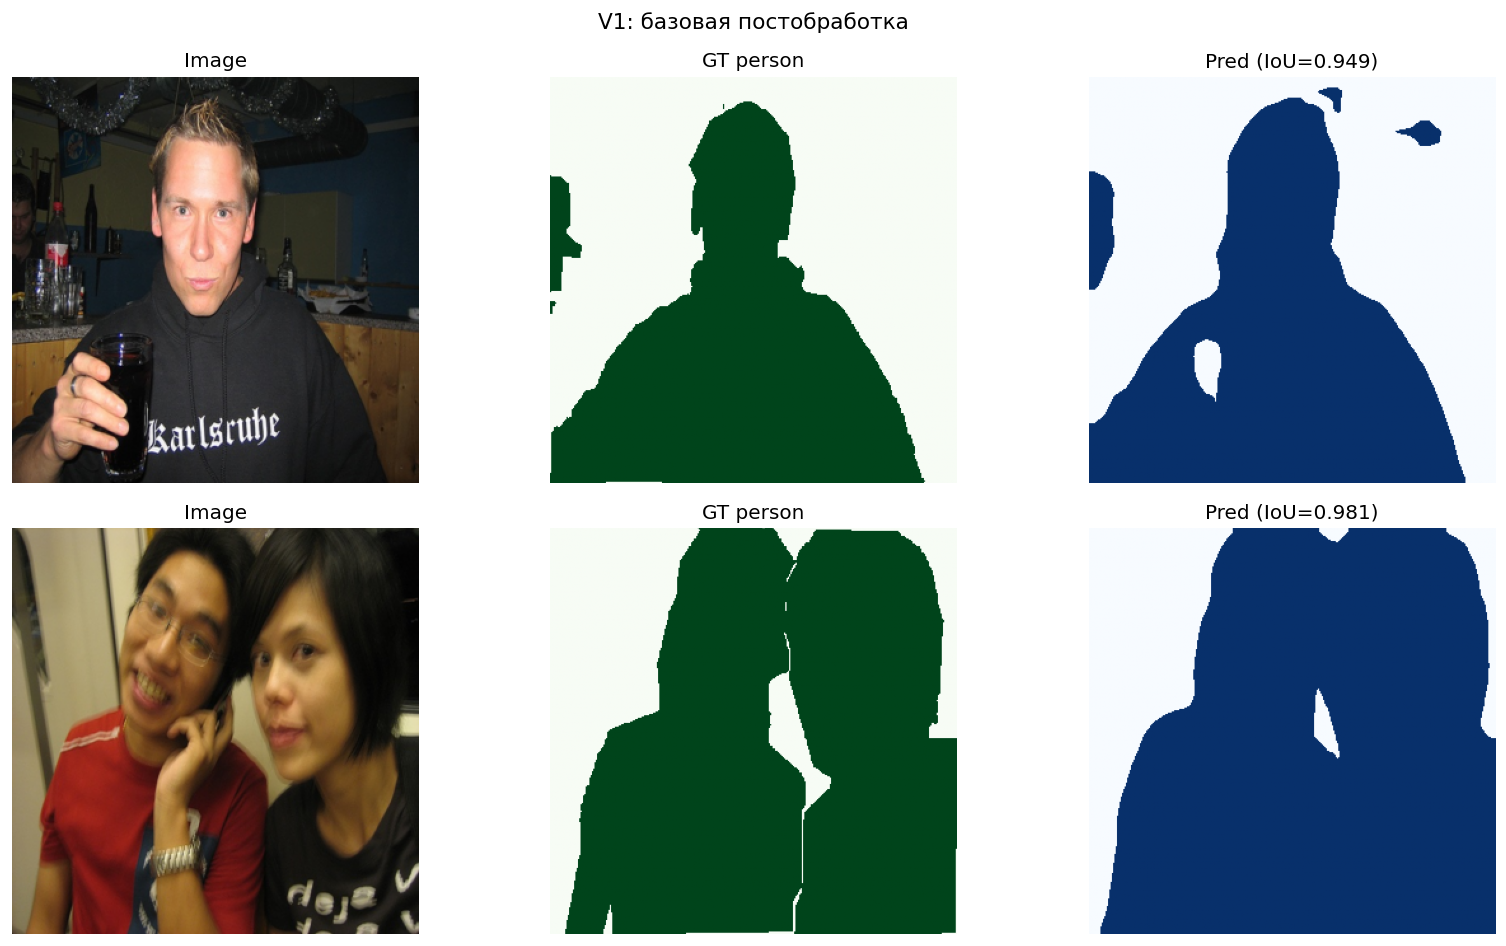

In [24]:
vp = [v for v in vis_v1 if v['m']['has_fg']][:4]
if len(vp)<2: vp = vis_v1[:4]
n = len(vp)
fig, axes = plt.subplots(n, 3, figsize=(14, 4*n))
if n==1: axes = axes[np.newaxis,:]
for i,v in enumerate(vp):
    axes[i][0].imshow(v['img']); axes[i][0].set_title('Image'); axes[i][0].axis('off')
    axes[i][1].imshow((v['gt']==FG).astype(float), cmap='Greens', vmin=0, vmax=1)
    axes[i][1].set_title('GT person'); axes[i][1].axis('off')
    axes[i][2].imshow((v['pred']==FG).astype(float), cmap='Blues', vmin=0, vmax=1)
    axes[i][2].set_title(f"Pred (IoU={v['m']['iou']:.3f})"); axes[i][2].axis('off')
fig.suptitle('V1: базовая постобработка', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,'segmentation_examples.png'), dpi=120, bbox_inches='tight')
plt.show()

  plt.show()


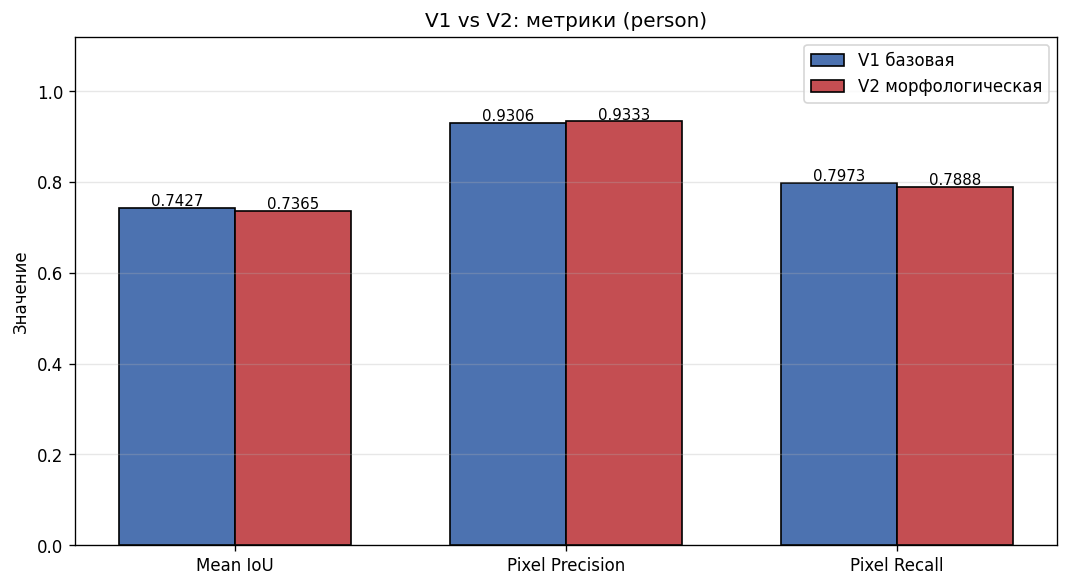

In [25]:
names = ['Mean IoU','Pixel Precision','Pixel Recall']
v1v = [s_v1['mean_iou'], s_v1['pix_prec'], s_v1['pix_rec']]
v2v = [s_v2['mean_iou'], s_v2['pix_prec'], s_v2['pix_rec']]
x = np.arange(len(names)); w=0.35
fig,ax=plt.subplots(figsize=(9,5))
b1=ax.bar(x-w/2,v1v,w,label='V1 базовая',color='#4C72B0',edgecolor='k')
b2=ax.bar(x+w/2,v2v,w,label='V2 морфологическая',color='#C44E52',edgecolor='k')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+.005,
            f'{b.get_height():.4f}', ha='center', fontsize=9)
ax.set_ylabel('Значение'); ax.set_title('V1 vs V2: метрики (person)')
ax.set_xticks(x); ax.set_xticklabels(names); ax.legend()
ax.set_ylim(0, max(max(v1v),max(v2v))*1.2); ax.grid(axis='y',alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,'segmentation_metrics.png'), dpi=120, bbox_inches='tight')
plt.show()

## 15. Итоговые артефакты

In [ ]:
fields = ['experiment_id','task','dataset','seed','model_summary','optimizer',
          'lr','epochs_trained','best_val_accuracy','test_accuracy',
          'precision','recall','mean_iou','notes']
rows = []
for eid in ['C1','C2','C3','C4']:
    r = results_a[eid]
    rows.append(dict(experiment_id=eid, task='classification', dataset='CIFAR-100',
                     seed=SEED, model_summary=r['ms'], optimizer=r['opt'],
                     lr=r['lr'], epochs_trained=r['ep'],
                     best_val_accuracy=round(r['ba'],6),
                     test_accuracy=round(test_acc,6) if eid==best_id else '',
                     precision='', recall='', mean_iou='', notes=r['note']))
rows.append(dict(experiment_id='V1', task='segmentation', dataset='Pascal VOC',
                 seed=SEED, model_summary='DeepLabV3_ResNet50', optimizer='', lr='',
                 epochs_trained='', best_val_accuracy='', test_accuracy='',
                 precision=round(s_v1['pix_prec'],6), recall=round(s_v1['pix_rec'],6),
                 mean_iou=round(s_v1['mean_iou'],6),
                 notes='Базовая постобработка (softmax threshold > 0.5), fg=person'))
rows.append(dict(experiment_id='V2', task='segmentation', dataset='Pascal VOC',
                 seed=SEED, model_summary='DeepLabV3_ResNet50', optimizer='', lr='',
                 epochs_trained='', best_val_accuracy='', test_accuracy='',
                 precision=round(s_v2['pix_prec'],6), recall=round(s_v2['pix_rec'],6),
                 mean_iou=round(s_v2['mean_iou'],6),
                 notes='Морфологическая очистка (opening 7x7), fg=person'))

with open(os.path.join(ARTIFACTS_DIR,'runs.csv'),'w',newline='',encoding='utf-8') as f:
    csv.DictWriter(f, fields).writeheader()
    csv.DictWriter(f, fields).writerows(rows)
print("runs.csv сохранён")

print()
print("="*65)
print("ИТОГО HW10-11")
print("="*65)
print(f"Часть A  лучший: {best_id}, val_acc={results_a[best_id]['ba']:.4f}, test_acc={test_acc:.4f}")
print(f"Часть B  V1: iou={s_v1['mean_iou']:.4f} prec={s_v1['pix_prec']:.4f} rec={s_v1['pix_rec']:.4f}")
print(f"         V2: iou={s_v2['mean_iou']:.4f} prec={s_v2['pix_prec']:.4f} rec={s_v2['pix_rec']:.4f}")
for p in ['artifacts/runs.csv','artifacts/best_classifier.pt',
          'artifacts/best_classifier_config.json',
          'artifacts/figures/classification_curves_best.png',
          'artifacts/figures/classification_compare.png',
          'artifacts/figures/augmentations_preview.png',
          'artifacts/figures/segmentation_examples.png',
          'artifacts/figures/segmentation_metrics.png']:
    print(f"  {'OK' if os.path.exists(p) else '!!'} {p}")
print("="*65)